**LR on small Apple stock dataset**

In [16]:
import polars as pl
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
import os
from datetime import datetime
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
# import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

In [ ]:
class Log_Regr():
    def __init__(self, test_size=0.3):
         self.test_size = test_size
         self.df_master = None
         
         # Distinct lists for each feature type
         self.price_cols = []
         self.tfidf_cols = []
         self.finbert_cols = []

    def _standardize_date(self, df, current_date_col_name):
        """Safely renames and formats the date column without touching TF-IDF word columns."""
        
        # Only rename if the column isn't already 'date_article'
        if current_date_col_name != "date_article":
            df = df.rename({current_date_col_name: "date_article"})
            
        # Parse strings to dates
        if df["date_article"].dtype == pl.String:
            df = df.with_columns(pl.col("date_article").str.to_date("%Y-%m-%d"))
            
        return df.sort("date_article")
    
    def _reorder_columns(self):
        """Forces readability: Date -> Target -> Price -> FinBERT -> TF-IDF"""
        if self.df_master is None:
            return
            
        # Create the ideal order
        ideal_order = ["date_article", "target_next_day"] + self.price_cols + self.finbert_cols + self.tfidf_cols
        
        # Filter the ideal order to only include columns we have actually loaded so far
        final_cols = [col for col in ideal_order if col in self.df_master.columns]
        
        self.df_master = self.df_master.select(final_cols)

    def _save_optimal_params(self, mode, n_rows, n_cols, best_params, cv_score):
        """Saves the optimal parameters from GridSearchCV to a JSON file."""
        file_path = "optimal_parameters.jsonl"
        
        log_entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "experiment": mode,
            "rows": n_rows,
            "features": n_cols,
            "best_cv_accuracy": round(cv_score, 4),
            "parameters": best_params
        }
        
        # 'a' means append mode. It won't overwrite previous runs.
        with open(file_path, 'a') as f:
            f.write(json.dumps(log_entry) + '\n')
            
        print(f"Optimal parameters saved to {file_path}")

    def load_and_prepare_price_data(self, df_prices, start_date=None, end_date=None):
        """
        Loads prices, creates Lags 1-5, and generates the Target variable.
        This forms the core timeline of df_master.
        """
        print("Loading prices, creating lags, and generating targets...")
        
        # Explicitly tell it to look for the lowercase 'date'
        df_prices = self._standardize_date(df_prices, "date")

        if start_date is not None and end_date is not None:
            df_prices = df_prices.filter(pl.col("date_article").is_between(start_date, end_date))

        # 2. Calculate return_lag0
        df_prices = df_prices.select([pl.col("date_article"), pl.col("close")])
        df_prices = df_prices.with_columns(pl.col("close").pct_change().alias("return_lag0"))       

        # 3. Create Target (Did price go UP tomorrow?)
        df_prices = df_prices.with_columns(
            (pl.col("return_lag0").shift(-1) > 0).cast(pl.Int8).alias("target_next_day")
        )        

        # 4. Create History (Lags 1-5)
        lags = 5
        lag_cols = ["return_lag0"] # Put return_lag0 back in the feature list
        for i in range(1, lags + 1):
            col_name = f"return_lag{i}"
            df_prices = df_prices.with_columns(
                pl.col("return_lag0").shift(i).alias(col_name)
            )
            lag_cols.append(col_name)

        self.price_cols = lag_cols

        # 5. Build Master DF
        cols_to_keep = ["date_article", "target_next_day"] + self.price_cols
        self.df_master = df_prices.select(cols_to_keep).drop_nulls()
        
        self._reorder_columns()
        print(f"Price timeline established. Shape: {self.df_master.shape}")
        display (self.df_master)
        return self.df_master
    
    def load_tfidf_data(self, df_tfidf):
        """
        Loads TF-IDF features and joins them to the stock target.
        """
        if self.df_master is None: raise ValueError("Run load_and_prepare_price_data first!")
            
        print("Loading TF-IDF data and aligning with timeline...")
        df_tfidf = self._standardize_date(df_tfidf, "Date")       
        
        self.tfidf_cols = [c for c in df_tfidf.columns if c != "date_article"]
        
        self.df_master = self.df_master.join(df_tfidf, on="date_article", how="left")
        self.df_master = self.df_master.fill_null(0)
        
        self._reorder_columns()
        print(f"TF-IDF aligned. Total columns in master: {len(self.df_master.columns)}")
        display (self.df_master)
        return self.df_master
    
    def prepare_price_data(self):
        pass
        # print("Integrating price features and creating history...")

        # # 1. Validation
        # if self.df_prices_raw is None:
        #     raise ValueError("Run load_stock_target first!")
        
        # # 1. Select return_lag0 from self.df_prices and join to self.df_master
        # price_returns = self.df_prices_raw.select(["date", "return_lag0"])

        # # 3. Join to Master
        # self.df_master = self.df_master.join(price_returns, on="date", how="left")
        
        # # 4. Create History (Lags 1-5)
        # lags = 5
        # lag_cols = ["return_lag0"] # Start with today
        
        # for i in range(1, lags + 1):
        #     col_name = f"return_lag{i}"
        #     self.df_master = self.df_master.with_columns(
        #         pl.col("return_lag0").shift(i).alias(col_name)
        #     )
        #     lag_cols.append(col_name)
            
        # # 3. Create Target (Tomorrow)
        # self.df_master = self.df_master.with_columns(
        #     (pl.col("return_lag0").shift(-1) > 0).cast(pl.Int8).alias("target_next_day")
        # )

        # # 4. Clean Nans (We lose the first 5 days because they don't have enough history)
        # self.df_master = self.df_master.drop_nulls()
        
        # # Update your class property to store the list of feature names
        # self.price_cols = lag_cols 
        # #self.sample_df_AAPL_prices = self.df_master
        # display(self.df_master)
        # return self.df_master

    def load_finbert_data(self, df_finbert):
        if self.df_master is None: raise ValueError("Run load_and_prepare_price_data first!")
            
        print("Loading FinBERT data and aligning with timeline...")
        df_finbert = self._standardize_date(df_finbert, "Date")       
        
        self.finbert_cols = [c for c in df_finbert.columns if c != "date_article"]
        
        self.df_master = self.df_master.join(df_finbert, on="date_article", how="left")
        self.df_master = self.df_master.fill_null(0)
        
        self._reorder_columns()
        print(f"FinBERT aligned. Total columns in master: {len(self.df_master.columns)}")
        display(self.df_master)
        return self.df_master

    def train_and_evaluate(self, mode):
        """
        Valid modes: 'price', 'tfidf', 'finbert', 'hybrid_tfidf', 'hybrid_finbert'
        """
        if self.df_master is None: raise ValueError("No data found.")
        
        # 1. Mode Selector
        active_features = []
        if mode == 'price':
            active_features = self.price_cols
        elif mode == 'tfidf':
            active_features = self.tfidf_cols
        elif mode == 'finbert':
            active_features = self.finbert_cols
        elif mode == 'hybrid_tfidf':
            active_features = self.price_cols + self.tfidf_cols 
        elif mode == 'hybrid_finbert':
            active_features = self.price_cols + self.finbert_cols
        else:
            raise ValueError(f"Invalid mode: {mode}")
            
        if not active_features:
            raise ValueError(f"No features found for mode '{mode}'. Did you load the data?")
        
        print(f"\nStarting Experiment: {mode.upper()} ({len(active_features)} features)")
        
        # 2. Arrays & Splits
        x = self.df_master.select(active_features).to_numpy()
        y = self.df_master["target_next_day"].to_numpy()
        X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=self.test_size, shuffle=False)

        # 3. Pipeline & GridSearch
        tscv = TimeSeriesSplit(n_splits=5)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('logr', LogisticRegression(solver='saga', class_weight='balanced', max_iter=2000))
        ])
        
        param_grid = {
            'logr__C': [0.1, 1.0, 10.0, 100.0],
            'logr__l1_ratio': [0.0, 0.1, 0.5, 0.9, 1.0] 
        }        
        print(f"\n--- Running GridSearchCV ({tscv.n_splits} splits) ---")
        
        grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # 4. Extract Results
        best_pipeline = grid_search.best_estimator_
        best_model = best_pipeline.named_steps['logr'] 
        
        print(f"Best Params: {grid_search.best_params_} | Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
        total_rows = len(x)
        total_features = len(active_features)
        self._save_optimal_params(mode, total_rows, total_features, grid_search.best_params_, grid_search.best_score_)

        y_pred = best_pipeline.predict(x_test)
        y_probs = best_pipeline.predict_proba(x_test)
        #accuracy = accuracy_score(y_test, y_pred)

        print("\n--- Final Model Reality Check (Untouched Test Set) ---")
        #print(f"First 5 Class Predictions: {y_pred[:5]}")
        print(f"Min Prob: {y_probs[:,1].min():.4f}, Max Prob: {y_probs[:,1].max():.4f}, Mean Prob: {y_probs[:,1].mean():.4f}")
        print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)'], zero_division=0))
        conf_matrix = confusion_matrix(y_test, y_pred)
        print("\nConfusion Matrix:")
        print(conf_matrix)

        # 5. Dynamic Weight Analysis
        coefs = best_model.coef_[0] 
        print("--- Weight Analysis ---")        
        price_weights, text_weights = np.array([]), np.array([])
        text_type = "None"

        if mode == 'price':
            price_weights = coefs
        elif mode == 'tfidf':
            text_weights = coefs
            text_type = "TF-IDF"
        elif mode == 'finbert':
            text_weights = coefs
            text_type = "FinBERT"
        elif mode == 'hybrid_tfidf':
            # Price is first, so we slice the first N columns for price
            num_price = len(self.price_cols)
            price_weights = coefs[:num_price]
            text_weights = coefs[num_price:]
            text_type = "TF-IDF"
        elif mode == 'hybrid_finbert':
            # Price is first, so we slice the first N columns for price
            num_price = len(self.price_cols)
            price_weights = coefs[:num_price]
            text_weights = coefs[num_price:]
            text_type = "FinBERT"

        # 6. Calculate and print stats
        if len(price_weights) > 0:
            print(f"Price Features Count: {len(price_weights)}")
            print(f"Average Absolute Price Weight: {np.mean(np.abs(price_weights)):.6f}")
        else:
            print("Price Features: [None in this mode]")

        if len(price_weights) > 0:
            print(f"Average Absolute Price Weight ({len(price_weights)} cols): {np.mean(np.abs(price_weights)):.6f}")
        if len(text_weights) > 0:
            print(f"Average Absolute {text_type} Weight ({len(text_weights)} cols): {np.mean(np.abs(text_weights)):.6f}")

        max_idx = np.argmax(np.abs(coefs))
        print(f"Most influential feature: '{active_features[max_idx]}' (Weight: {coefs[max_idx]:.4f})")

        # --- 1. ROC Curve ---
        plt.figure(figsize=(8, 6))
        RocCurveDisplay.from_estimator(best_pipeline, x_test, y_test)
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray") # Random guess line
        plt.title("ROC Curve: Signal vs. Noise")
        plt.show()

        # --- 2. Money Chart (Simple Version) ---
        # We need the actual returns from the test period
        # Assuming your df_master is still aligned with the test set
        test_returns = self.df_master.tail(len(y_pred))["return_lag0"].to_numpy()

        # Strategy: If pred == 1, hold stock. If pred == 0, hold cash.
        strategy_returns = y_pred * test_returns

        # Calculate Cumulative Growth (1 + r).cumprod()
        cum_strategy = np.insert((1 + strategy_returns).cumprod(), 0, 1.0)
        cum_market = np.insert((1 + test_returns).cumprod(), 0, 1.0)

        plt.figure(figsize=(10, 5))
        plt.plot(cum_strategy, label="Model Strategy", linewidth=2)
        plt.plot(cum_market, label="Market (Buy & Hold)", linestyle="--")
        plt.title("Cumulative Returns: Model vs. Market")
        plt.ylabel("Growth of $1")
        plt.legend()
        plt.show()
        
        return x_test, y_pred

In [71]:
#load stock price data - for now take just a sample to speed up testing within timeframe
n_rows  = 1500
sample_csv_AAPL_prices = pl.read_csv('full_stock_prices/AAPL.csv', n_rows=n_rows)

In [5]:
n_rows  = 2000
df_tfidf_raw = pl.read_parquet('full_news/tfidf_complete_nasdaq.parquet')

In [50]:
df_finbert_raw = pl.read_parquet('full_news/finbert_2019_ALL_nasdaq_avg_sentiment_2019_Jan-Jun.parquet')

In [ ]:
df_tfidf = df_tfidf_raw.filter(
                pl.col("Date").is_between(pl.date(2019, 10, 4), pl.date(2023, 12, 28))
            )


In [89]:
if sample_csv_AAPL_prices["date"].dtype == pl.String:
            sample_csv_AAPL_prices = sample_csv_AAPL_prices.with_columns(pl.col("date").str.to_date("%Y-%m-%d"))

sample_csv_AAPL_prices = sample_csv_AAPL_prices.filter(
                pl.col("date").is_between(pl.date(2019, 1, 1), pl.date(2019, 2, 1))
            )

In [90]:
display(sample_csv_AAPL_prices.sort("date"))

date,open,high,low,close,adj close,volume
date,f64,f64,f64,f64,f64,i64
2019-01-02,154.889999,158.850006,154.229996,157.919998,155.214005,37039700
2019-01-03,143.979996,145.720001,142.0,142.190002,139.75354,91312200
2019-01-04,144.529999,148.550003,143.800003,148.259995,145.719513,58607100
2019-01-07,148.699997,148.830002,145.899994,147.929993,145.395203,54777800
2019-01-08,149.559998,151.820007,148.520004,150.75,148.16687,41025300
…,…,…,…,…,…,…
2019-01-28,155.789993,156.330002,153.660004,156.300003,153.621765,26192100
2019-01-29,156.25,158.130005,154.110001,154.679993,152.02951,41587200
2019-01-30,163.25,166.149994,160.229996,165.25,162.418411,61109800


In [28]:
display(df_tfidf.sort("Date"))

Date,aa,aaa,aanum,aapl,aaron,ab,abandon,abb,abba,abbott,abbvi,abc,abe,abercrombi,aberdeen,abi,abil,abort,abroad,absolut,abu,abus,ac,acacia,academ,academi,acceler,accentur,accept,access,accessori,accid,accord,account,accredit,accus,…,xom,xstrata,xtracker,yahoo,yanke,ye,year,yearend,yearli,yellen,yellow,yelp,yemen,yen,yhoo,yield,yld,york,young,youth,youtub,yoy,yr,yryr,yuan,yum,yy,zack,zealand,zero,zika,zimbabw,zinc,zion,zloti,zone,zynga
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-04,0.000756,0.0,0.0,0.024789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003764,0.000798,0.001415,0.0,0.0,0.0,0.0,0.0,0.023717,0.0,0.0,0.0,…,0.003791,0.0,0.0,0.0,0.0,0.0,0.030874,0.00076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.13418,0.0,0.000599,0.0,0.0,0.0,0.0,0.000823,0.0,0.0,0.0,0.001532,0.038473,0.0,0.0,0.0,0.0,0.0,0.003934,0.0,0.0,0.0
2023-10-05,0.000634,0.0,0.0,0.0,0.003731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001926,0.0,0.0,0.0,0.0,0.0,0.0,0.001509,0.0,0.0,0.0,0.0,0.0,0.002967,0.0,0.0,0.0,0.0,0.0,0.001755,0.0,0.0,0.0,…,0.033916,0.0,0.0,0.0,0.0,0.00087,0.011236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.117444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00091,0.001285,0.008687,0.0,0.0,0.0,0.0,0.0,0.0033,0.0,0.00228,0.0
2023-10-06,0.002359,0.0,0.0,0.031498,0.0,0.0,0.0,0.0,0.0,0.0,0.002552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001566,0.0,0.0,0.0,0.0,0.000736,0.0,0.0,0.0,0.0,0.0,0.002176,0.0,0.0,0.0,…,0.085401,0.0,0.0,0.0,0.0,0.0,0.029068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.109699,0.0,0.000623,0.0,0.0,0.001802,0.0,0.0,0.0,0.0,0.002256,0.003186,0.014614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-10-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.014018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015674,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-10-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.013643,0.00335,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.002848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.108281,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023-12-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.124198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
display(df_finbert_raw.sort("Date"))

Date,avg_pos,avg_neg,avg_neu,daily_article_count
date,f32,f32,f32,u32
2019-01-01,0.334333,0.134419,0.531248,285
2019-01-02,0.23481,0.214964,0.550226,2242
2019-01-03,0.238234,0.226136,0.535629,2265
2019-01-04,0.272344,0.202279,0.525378,2082
2019-01-05,0.138821,0.196904,0.664275,221
…,…,…,…,…
2019-06-16,0.157676,0.156472,0.685852,398
2019-06-17,0.249435,0.158641,0.591924,1727
2019-06-18,0.277369,0.146676,0.575955,1959


In [91]:
Log_Regr_Object = Log_Regr(test_size=0.3)

In [92]:
sample_df_AAPL_prices = Log_Regr_Object.load_and_prepare_price_data(sample_csv_AAPL_prices)

Loading prices, creating lags, and generating targets...
Price timeline established. Shape: (15, 8)


date_article,target_next_day,return_lag0,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5
date,i8,f64,f64,f64,f64,f64,f64
2019-01-10,0,0.003196,0.016982,0.019063,-0.002226,0.042689,-0.099607
2019-01-11,0,-0.009818,0.003196,0.016982,0.019063,-0.002226,0.042689
2019-01-14,1,-0.015037,-0.009818,0.003196,0.016982,0.019063,-0.002226
2019-01-15,1,0.020467,-0.015037,-0.009818,0.003196,0.016982,0.019063
2019-01-16,1,0.012217,0.020467,-0.015037,-0.009818,0.003196,0.016982
…,…,…,…,…,…,…,…
2019-01-25,0,0.033137,-0.007926,0.004044,-0.022446,0.006159,0.005938
2019-01-28,0,-0.009255,0.033137,-0.007926,0.004044,-0.022446,0.006159
2019-01-29,1,-0.010365,-0.009255,0.033137,-0.007926,0.004044,-0.022446


In [78]:
sample_df_AAPL_prices = Log_Regr_Object.load_tfidf_data(df_tfidf)

Loading TF-IDF data and aligning with timeline...
TF-IDF aligned. Total columns in master: 5008


date_article,target_next_day,return_lag0,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,aa,aaa,aanum,aapl,aaron,ab,abandon,abb,abba,abbott,abbvi,abc,abe,abercrombi,aberdeen,abi,abil,abort,abroad,absolut,abu,abus,ac,acacia,academ,academi,acceler,accentur,accept,…,xom,xstrata,xtracker,yahoo,yanke,ye,year,yearend,yearli,yellen,yellow,yelp,yemen,yen,yhoo,yield,yld,york,young,youth,youtub,yoy,yr,yryr,yuan,yum,yy,zack,zealand,zero,zika,zimbabw,zinc,zion,zloti,zone,zynga
date,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2019-01-09,1,0.016982,0.019063,-0.002226,0.042689,-0.099607,0.001141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-10,0,0.003196,0.016982,0.019063,-0.002226,0.042689,-0.099607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-11,0,-0.009818,0.003196,0.016982,0.019063,-0.002226,0.042689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-14,1,-0.015037,-0.009818,0.003196,0.016982,0.019063,-0.002226,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-01-15,1,0.020467,-0.015037,-0.009818,0.003196,0.016982,0.019063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2019-06-14,1,-0.007262,-0.000206,-0.003183,0.01158,0.012779,0.026617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-17,1,0.005967,-0.007262,-0.000206,-0.003183,0.01158,0.012779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06-18,0,0.023518,0.005967,-0.007262,-0.000206,-0.003183,0.01158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
final_df = Log_Regr_Object.load_finbert_data(df_finbert_raw)

Loading FinBERT data and aligning with timeline...
FinBERT aligned. Total columns in master: 12


date_article,target_next_day,return_lag0,return_lag1,return_lag2,return_lag3,return_lag4,return_lag5,avg_pos,avg_neg,avg_neu,daily_article_count
date,i8,f64,f64,f64,f64,f64,f64,f32,f32,f32,u32
2019-01-10,0,0.003196,0.016982,0.019063,-0.002226,0.042689,-0.099607,0.262297,0.236973,0.50073,2362
2019-01-11,0,-0.009818,0.003196,0.016982,0.019063,-0.002226,0.042689,0.24215,0.203139,0.554711,2098
2019-01-14,1,-0.015037,-0.009818,0.003196,0.016982,0.019063,-0.002226,0.243948,0.220703,0.535349,2368
2019-01-15,1,0.020467,-0.015037,-0.009818,0.003196,0.016982,0.019063,0.274906,0.174756,0.550338,2323
2019-01-16,1,0.012217,0.020467,-0.015037,-0.009818,0.003196,0.016982,0.240581,0.196144,0.563274,2382
…,…,…,…,…,…,…,…,…,…,…,…
2019-01-25,0,0.033137,-0.007926,0.004044,-0.022446,0.006159,0.005938,0.294392,0.170943,0.534665,2154
2019-01-28,0,-0.009255,0.033137,-0.007926,0.004044,-0.022446,0.006159,0.250088,0.225476,0.524437,2614
2019-01-29,1,-0.010365,-0.009255,0.033137,-0.007926,0.004044,-0.022446,0.260363,0.20157,0.538067,3214



Starting Experiment: PRICE (6 features)

--- Running GridSearchCV (5 splits) ---
Best Params: {'logr__C': 0.1, 'logr__l1_ratio': 1.0} | Best Cross-Validation Accuracy: 0.5667
Optimal parameters saved to optimal_parameters.jsonl

--- Final Model Reality Check (Untouched Test Set) ---
Min Prob: 0.4795, Max Prob: 0.4795, Mean Prob: 0.4795
Final Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.50      1.00      0.67         8
      Up (1)       0.00      0.00      0.00         8

    accuracy                           0.50        16
   macro avg       0.25      0.50      0.33        16
weighted avg       0.25      0.50      0.33        16


Confusion Matrix:
[[8 0]
 [8 0]]
--- Weight Analysis ---
Price Features Count: 6
Average Absolute Price Weight: 0.000000
Average Absolute Price Weight (6 cols): 0.000000
Most influential feature: 'return_lag0' (Weight: 0.0000)


<Figure size 800x600 with 0 Axes>

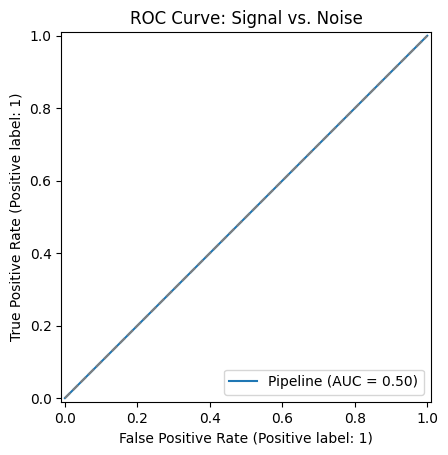

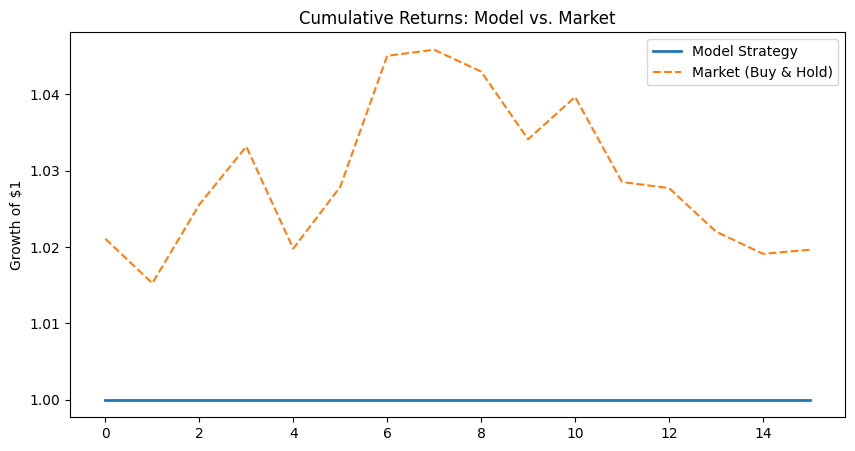

In [35]:
x_test_price, y_pred_price = Log_Regr_Object.train_and_evaluate(mode='price')


Starting Experiment: HYBRID_TFIDF (5006 features)

--- Running GridSearchCV (5 splits) ---
Best Params: {'logr__C': 10.0, 'logr__l1_ratio': 1.0} | Best Cross-Validation Accuracy: 0.5474
Optimal parameters saved to optimal_parameters.jsonl

--- Final Model Reality Check (Untouched Test Set) ---
Min Prob: 0.0000, Max Prob: 1.0000, Mean Prob: 0.5804
Final Test Accuracy: 0.5338

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.47      0.41      0.44        66
      Up (1)       0.57      0.63      0.60        82

    accuracy                           0.53       148
   macro avg       0.52      0.52      0.52       148
weighted avg       0.53      0.53      0.53       148


Confusion Matrix:
[[27 39]
 [30 52]]
--- Weight Analysis ---
Price Features Count: 6
Average Absolute Price Weight: 0.052370
Average Absolute Price Weight (6 cols): 0.052370
Average Absolute TF-IDF Weight (5000 cols): 0.013555
Most influential feature: 'thought' (Weight

c:\Users\jankovic\Documents\Bachelorarbeit\Experiments\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


<Figure size 800x600 with 0 Axes>

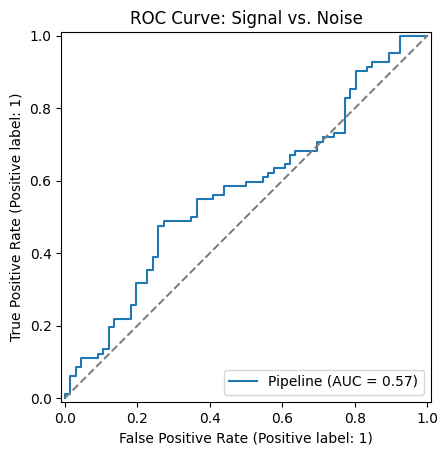

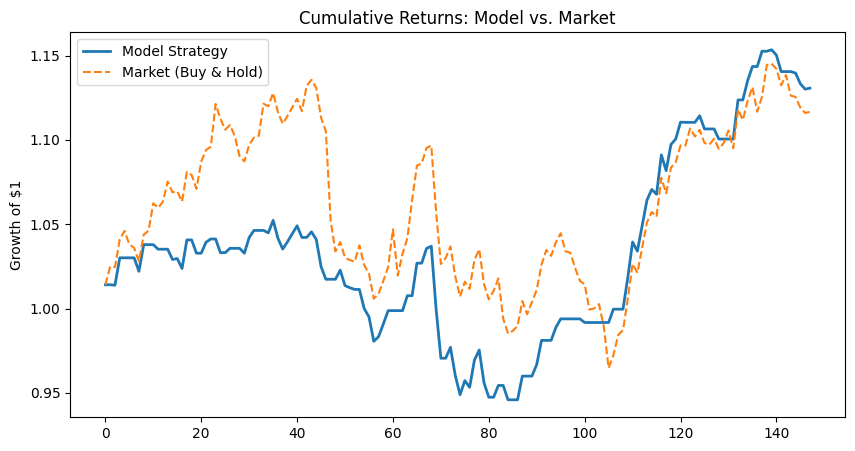

In [24]:
x_test_tf, y_pred_tf = Log_Regr_Object.train_and_evaluate(mode='hybrid_tfidf')


Starting Experiment: FINBERT (4 features)

--- Running GridSearchCV (5 splits) ---
Best Params: {'logr__C': 0.1, 'logr__l1_ratio': 0.0} | Best Cross-Validation Accuracy: 0.6000
Optimal parameters saved to optimal_parameters.jsonl

--- Final Model Reality Check (Untouched Test Set) ---
Min Prob: 0.4362, Max Prob: 0.6651, Mean Prob: 0.5555
Final Test Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

    Down (0)       1.00      0.50      0.67         2
      Up (1)       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5


Confusion Matrix:
[[1 1]
 [0 3]]
--- Weight Analysis ---
Price Features: [None in this mode]
Average Absolute FinBERT Weight (4 cols): 0.096614
Most influential feature: 'daily_article_count' (Weight: 0.1754)


<Figure size 800x600 with 0 Axes>

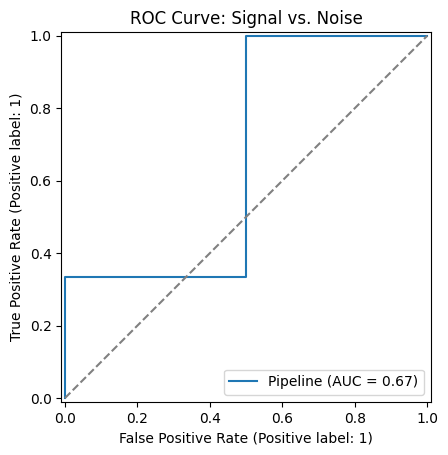

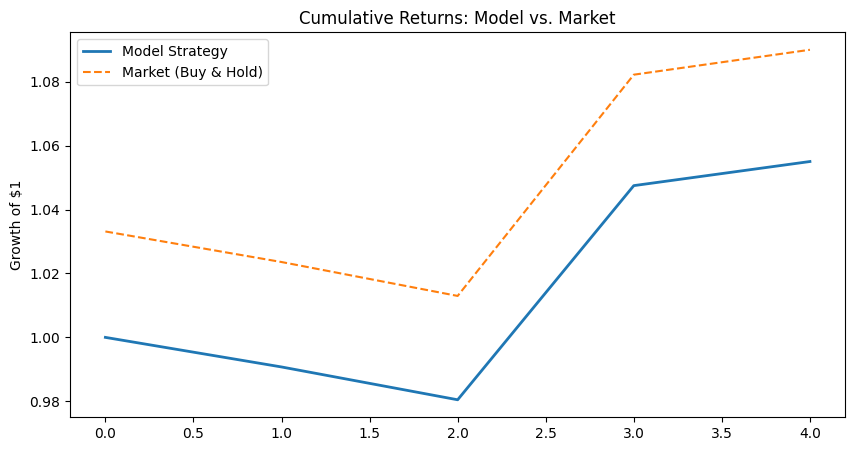

In [94]:
x_test_hybrid, y_pred_hybrid = Log_Regr_Object.train_and_evaluate(mode='finbert')

In [15]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# This actually looks professional and scientific
RocCurveDisplay.from_estimator(best_pipeline, x_test, y_test)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--") # The "Random Guess" line
plt.title("ROC Curve: Can the model distinguish Up from Down?")
plt.show()

NameError: name 'best_pipeline' is not defined

**Random Forest on small Apple stock dataset**

In [3]:
def RandomForestTuned(dataset, n_rows):
    sample_df_APPL = pl.read_csv(dataset, n_rows=n_rows)

    sample_df_APPL = sample_df_APPL.sort("date").with_row_index("id").select([pl.col("id"),
        pl.col("date"),pl.col("open"),pl.col("high"), pl.col("low"),pl.col("volume"), pl.col("close")
                                                                ]).with_columns(
            (pl.col("close") > pl.col("close").shift(1)).cast(pl.Int8).alias("up/down"))

    sample_df_APPL = sample_df_APPL.filter(pl.col("close").is_not_null())
    sample_df_APPL = sample_df_APPL.drop_nulls(subset=["up/down"])
    x = sample_df_APPL.select(["open", "high", "low", "volume", "close"]).to_numpy()
    #form of X is: [[5.1 3.5 1.4 0.2]
    #               [4.9 3.  1.4 0.2]
    #                [4.7 3.2 1.3 0.2]
    y = sample_df_APPL.select("up/down").to_numpy().flatten()
    
    # 1. Setup TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    
    # 2. Define the parameter grid
    param_dist = {
        'n_estimators': [100, 200, 300, 500],        # More trees to smooth out noise
        'max_depth': [10, 20, 30, None],             # Limit depth to prevent memorization
        'min_samples_split': [20, 50, 100],          # High values to ignore outliers
        'min_samples_leaf': [10, 20, 40],            # High values for robust rules
        'max_features': ['sqrt', 1.0],               # Try using all features vs subset
        'bootstrap': [True]                          # Keep True for stability
    }

    print(f"Starting RandomizedSearchCV with {tscv.get_n_splits()} time-series splits...")

    # 3. Setup Random Search
    rf = RandomForestClassifier(random_state=42)
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=20,              # Try 20 random combinations
        cv=tscv,                # STRICTLY use TimeSeriesSplit
        scoring='accuracy',     
        n_jobs=-1,
        random_state=42
    )

    # 4. Fit (This runs the loop logic internally, respecting time order)
    random_search.fit(x, y)

    print(f"\nBest Accuracy Score found: {random_search.best_score_ * 100:.2f}%")
    print("Best Parameters:")
    print(random_search.best_params_)

    # 5. Evaluate the BEST model on the most recent data (Last Split)
    # We reconstruct the last split manually to visualize results for the latest data period
    train_index, test_index = list(tscv.split(x))[-1]
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Get the best trained model from search
    best_model = random_search.best_estimator_
    
    # Note: best_estimator_ is refitted on the whole X,y by default. 
    # To see its performance on unseen future data specifically for this 'last split' visualization,
    # we can re-fit it on just the training part of the last split, OR accept that 
    # it has seen this data in the final refit. 
    # For strict evaluation visualization, let's fit a fresh clone on the train portion:
    from sklearn.base import clone
    final_model = clone(best_model)
    final_model.fit(X_train, y_train)
    
    y_pred = final_model.predict(X_test)
    
    print(f"\nAccuracy on final test split: {accuracy_score(y_test, y_pred) * 100:.2f}%")

    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    target_names = ['Down (0)', 'Up (1)']
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
                xticklabels=target_names, yticklabels=target_names)

    plt.title('Confusion Matrix Heatmap (Best Model)')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    feature_importances = final_model.feature_importances_
    feature_names = ["open", "high", "low", "volume", "close"]

    plt.barh(feature_names, feature_importances)
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance in Best Random Forest Classifier')
    plt.show()

Starting RandomizedSearchCV with 5 time-series splits...

Best Accuracy Score found: 55.15%
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}

Accuracy on final test split: 54.55%


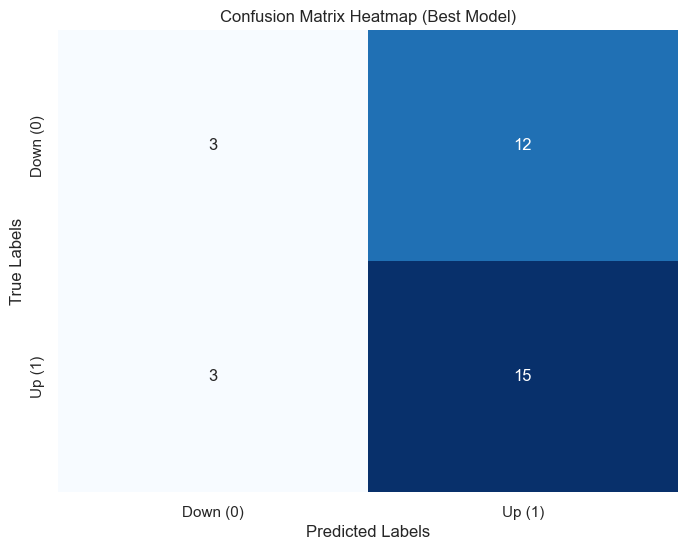

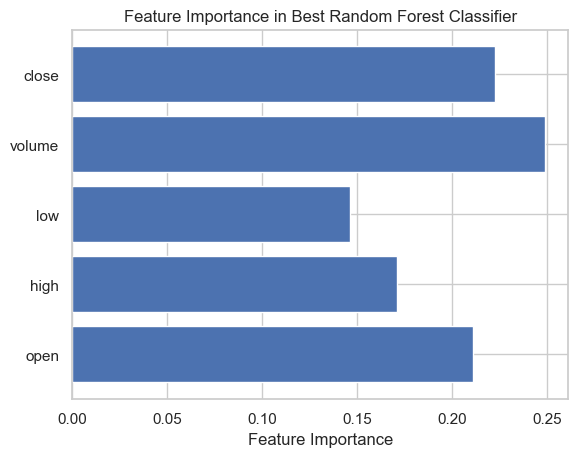

In [11]:
RandomForestTuned('full_stock_prices/AAPL.csv',200)

Starting RandomizedSearchCV with 5 time-series splits...

Best Accuracy Score found: 56.34%
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 1.0, 'max_depth': 30, 'bootstrap': True}

Accuracy on final test split: 63.96%


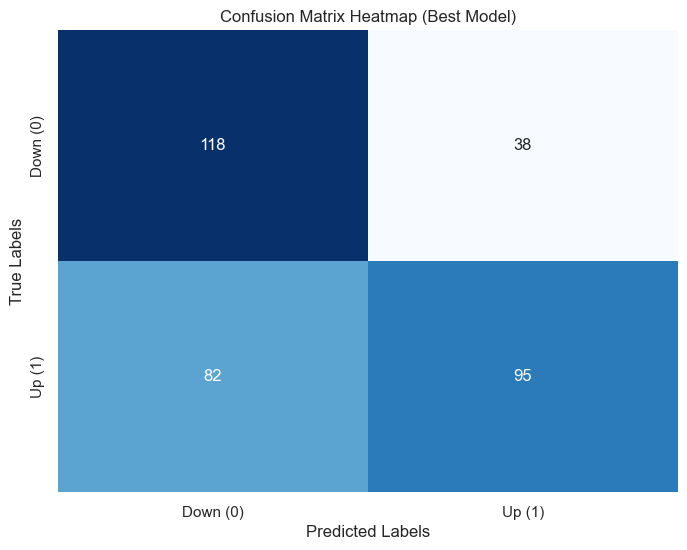

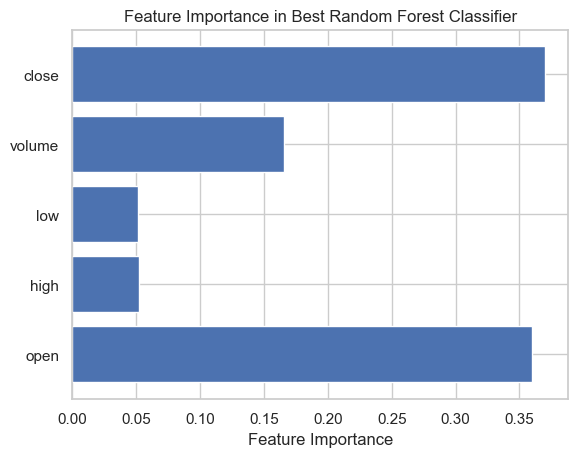

In [13]:
RandomForestTuned('full_stock_prices/AAPL.csv',2000)

Starting RandomizedSearchCV with 5 time-series splits...

Best Accuracy Score found: 57.21%
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 1.0, 'max_depth': 30, 'bootstrap': True}

Accuracy on final test split: 47.18%


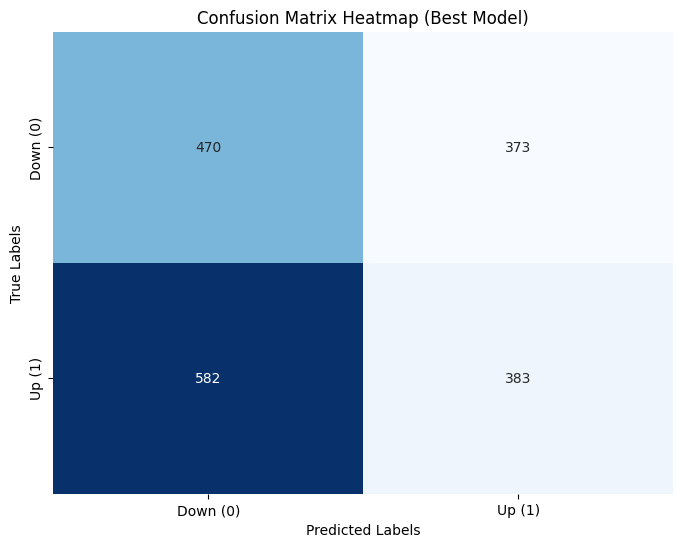

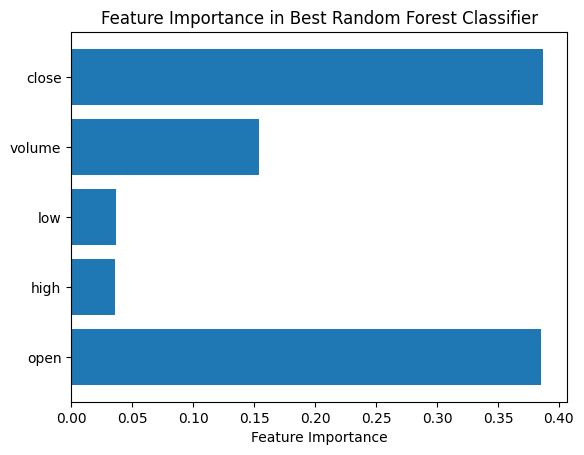

In [4]:
RandomForestTuned('full_stock_prices/AAPL.csv',20000)